In [2]:
import os
import pandas as pd

df = pd.read_csv("products.csv")
df.head()

,name,description,image_url,file_name
0,Milka Alpenmilch,"je 250-g-Tafel, (1 kg = 11,96 €)",https://shop.rewe-static.de/content-offer-rend...,2663ce16-8dab-49c1-9518-0c249249c8e7
1,Barilla Pesto,"Rosso, je 200-g-Glas, (1 kg = 9,95 €)",https://shop.rewe-static.de/content-offer-rend...,e7bb42bf-f2a3-438b-8991-56105c4c7e15
2,Haribo Goldbären,"je 175-g-Btl., (1 kg = 3,94 €)",https://img.rewe-static.de/REWE_DORTMUND27_202...,3e68d942-c066-436a-affd-cbc09953ff46
3,Gerri Limonade,"versch. Sorten, je 12 x 1-l-Fl.-Kasten, (1 l =...",https://img.rewe-static.de/REWE_DORTMUND27_202...,177362e5-f69b-40ce-8667-7d529dd3f708
4,Dr. Oetker Die Ofenfrische Vier Käse,"tiefgefroren, je 410-g-Pckg., (1 kg = 4,85 €)",https://img.rewe-static.de/REWE_DORTMUND27_202...,0f598e0b-6390-4126-a8e2-19641f9333cb


In [7]:
df.shape

(308, 4)

In [9]:
import torch
from transformers import AutoModel, AutoProcessor


if not torch.cuda.is_available():
    raise OSError("No cuda available!")

model_id = "jinaai/jina-embeddings-v5-omni-nano"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True, default_task="retrieval").eval().to("cuda")
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/780 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

In [10]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

client = QdrantClient(url="http://localhost:6333")

In [12]:
embedding = model.embed(**processor(text="test", return_tensors="pt").to(model.device))
embedding.shape

torch.Size([1, 768])

In [57]:
collection_name = "products"

client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=embedding.shape[-1], distance=Distance.DOT),
)

client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='products')])

In [69]:
from PIL import Image
from loguru import logger
from tqdm import tqdm

points = []

for (_, (product_name, desc, url, file_name)) in tqdm(df.iterrows(), total=df.shape[0]):
    try:
        image_path = os.path.join("./data", f"{file_name}.jpg")
        image = Image.open(image_path)
        vector = model.embed(**processor(image, text="<image>", return_tensors="pt").to(model.device)).tolist()[0]

        point = PointStruct(
            id=file_name,
            vector=vector,
            payload={
                "image_path": image_path,
                "name": product_name,
                "description": desc
            }
        )
        points.append(point)
        logger.info(product_name)
    except Exception:
        #logger.error(f"Couldn't upload {product_name}: {e}")
        continue
        

  0%|          | 0/308 [00:00<?, ?it/s]2026-06-28 19:44:36.434 | INFO     | __main__:<module>:24 - Haribo Goldbären
2026-06-28 19:44:36.487 | INFO     | __main__:<module>:24 - Gerri Limonade
  1%|▏         | 4/308 [00:00<00:09, 33.73it/s]2026-06-28 19:44:36.544 | INFO     | __main__:<module>:24 - Dr. Oetker Die Ofenfrische Vier Käse
2026-06-28 19:44:36.599 | INFO     | __main__:<module>:24 - Barilla Classic Pasta
2026-06-28 19:44:36.653 | INFO     | __main__:<module>:24 - Ben & Jerry’s Ice Cream
  3%|▎         | 8/308 [00:00<00:10, 27.32it/s]2026-06-28 19:44:36.709 | INFO     | __main__:<module>:24 - Red Bull Energy Drink
2026-06-28 19:44:36.763 | INFO     | __main__:<module>:24 - Hanuta
  4%|▎         | 11/308 [00:00<00:10, 27.37it/s]2026-06-28 19:44:36.823 | INFO     | __main__:<module>:24 - Ben & Jerry’s Ice Cream
2026-06-28 19:44:36.878 | INFO     | __main__:<module>:24 - Dallmayr Crema d’Oro
 15%|█▍        | 45/308 [00:00<00:02, 125.69it/s]2026-06-28 19:44:36.933 | INFO     | __ma

In [38]:
len(points)

240

In [58]:
client.upsert(collection_name=collection_name, points=points)

UpdateResult(operation_id=1, status=<UpdateStatus.COMPLETED: 'completed'>)

In [59]:
info = client.get_collection(collection_name=collection_name)
info.points_count

240

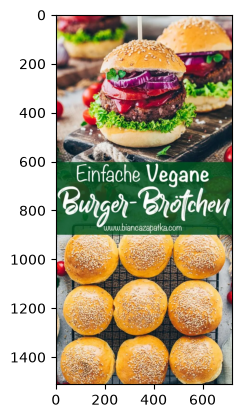

In [74]:
import matplotlib.pyplot as plt

query = Image.open("./query_images/vegane-burger-buns.jpg")

plt.imshow(query)
plt.show()

In [75]:
embedded_query = model.embed(**processor(query, text="<image>", return_tensors="pt").to(model.device)).tolist()[0]

In [76]:
search_result = client.query_points(
    collection_name=collection_name,
    query=embedded_query,
    limit=5,
    with_payload=True
)

In [77]:
for res in search_result.points:
    print(f"Name: {res.payload["name"]} - Score: {res.score}")


Name: Butcher’s Burger Buns - Score: 0.45400283
Name: REWE Beste Wahl Burger Patties - Score: 0.4314502
Name: REWE Beste Wahl pflanzliche Burger Patties - Score: 0.3758603
Name: REWE Beste Wahl pflanzliche Bratwurst - Score: 0.3341607
Name: Bürger Kartoffel-Schupfnudeln oder Schwäbische Eierspätzle - Score: 0.33232123
